<a href="https://colab.research.google.com/github/D1778/ML-lab-2547220/blob/LAB9/LAB9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 9 - Support Vector Machine (SVM) and Principal Component Analysis (PCA)

Aim

To implement Support Vector Machine (SVM) for classification and Principal Component
Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real world datasets.

Objectives
1. To implement and evaluate the performance of the Support Vector Machine (SVM)
classifier using different kernel functions.
2. To compare the performance of SVM models using standard classification metrics.
3. To apply Principal Component Analysis (PCA) for reducing the dimensionality of a high
dimensional dataset.
4. To analyse the variance retained by the principal components and visualize the
transformed feature space.
5. To understand the role of supervised learning (SVM) and unsupervised learning (PCA) in
machine learning applications.


Part A: Support Vector Machine (SVM)

Aim:
To implement the Support Vector Machine (SVM) classifier for a binary classification problem
and evaluate its performance.

Dataset:
UCI Breast Cancer Wisconsin (Diagnostic) Dataset
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

TASK 1. Load the dataset and perform the necessary preprocessing.

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Define column names
columns = [
    "id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave_points_mean", "symmetry_mean",
    "fractal_dimension_mean", "radius_se",
    "texture_se","perimeter_se", "area_se", "smoothness_se", "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

# Load the dataset
df = pd.read_csv("wdbc.csv", header=None, names=columns)

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

# Separate the target variable
y = df["diagnosis"]

# Remove ID and target column from input features
X = df.drop(columns=["id", "diagnosis"])

# Encode the target variable
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Standardize the input features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("\nPreprocessed Feature Shape:")
print(X.shape)

print("\nEncoded Target Classes:")
print(encoder.classes_)

Dataset Shape:
(569, 32)

First 5 Rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Preprocessed Feature Shape:
(569, 30)

Encoded Target Classes:
['B' 'M']


TASK 2. Split the dataset into training and testing sets (80:20).


In [3]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)
print("Training Labels Shape  :", y_train.shape)
print("Testing Labels Shape   :", y_test.shape)

Training Features Shape: (455, 30)
Testing Features Shape : (114, 30)
Training Labels Shape  : (455,)
Testing Labels Shape   : (114,)


TASK 3. Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning.


In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# Train an SVM classifier using a Linear Kernel

svm_model = SVC(kernel="linear", C=1)

svm_model.fit(X_train, y_train)

# Predict the test dataset

y_pred = svm_model.predict(X_test)

# Calculate test accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Linear SVM Accuracy:", accuracy)


# Explore different values of C

C_values = [0.01, 0.1, 1, 10, 100]

results = []

for c in C_values:

    model = SVC(kernel="linear", C=c)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([c, accuracy])


# Display hyperparameter tuning results

results_df = pd.DataFrame(
    results,
    columns=["C Value", "Test Accuracy"]
)

print("\nSVM Hyperparameter Tuning Results:")
display(results_df)


# Find the best C value

best_c = results_df.loc[
    results_df["Test Accuracy"].idxmax(),
    "C Value"
]

best_accuracy = results_df["Test Accuracy"].max()

print("\nBest C Value:", best_c)
print("Best Test Accuracy:", best_accuracy)

Linear SVM Accuracy: 0.9649122807017544

SVM Hyperparameter Tuning Results:


,C Value,Test Accuracy
0,0.01,0.956140
1,0.10,0.982456
2,1.00,0.964912
3,10.00,0.982456
4,100.00,0.929825



Best C Value: 0.1
Best Test Accuracy: 0.9824561403508771


TASK 4. Evaluate the model using:

○ Accuracy

○ Precision

○ Recall

○ F1 Score

○ Confusion Matrix

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Train the SVM model using the best C value

best_svm_model = SVC(
    kernel="linear",
    C=best_c
)

best_svm_model.fit(X_train, y_train)

# Predict the test dataset

y_pred = best_svm_model.predict(X_test)


# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# Calculate Precision

precision = precision_score(y_test, y_pred)

print("Precision:", precision)


# Calculate Recall

recall = recall_score(y_test, y_pred)

print("Recall:", recall)


# Calculate F1 Score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)


# Display Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9523809523809523
F1 Score: 0.975609756097561

Confusion Matrix:
[[72  0]
 [ 2 40]]


TASK 5. Summarize your observations.

The Linear SVM classifier performed well on the WDBC dataset and achieved good classification accuracy. Hyperparameter tuning showed that changing the value of C affected the model's test performance, with the best value selected based on the highest test accuracy. The accuracy, precision, recall, F1 score, and confusion matrix indicate that the trained SVM can effectively distinguish between benign and malignant cases.


Part B: Principal Component Analysis (PCA)

Aim:

To implement Principal Component Analysis (PCA) for dimensionality reduction and analyse
the variance retained by the principal components.

Dataset:
UCI Wine Dataset
https://archive.ics.uci.edu/dataset/109/wine

TASK 1. Load the dataset and perform feature standardization.


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the Wine dataset
df_wine = pd.read_csv("wine.csv", header=None)

print("Dataset Shape:")
print(df_wine.shape)

print("\nFirst 5 Rows:")
display(df_wine.head())

# Separate the target variable and input features
y_wine = df_wine.iloc[:, 0]
X_wine = df_wine.iloc[:, 1:]

print("\nOriginal Feature Shape:")
print(X_wine.shape)

# Standardize the input features
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("\nStandardized Feature Shape:")
print(X_wine_scaled.shape)

print("\nFirst 5 Standardized Rows:")
display(pd.DataFrame(X_wine_scaled).head())

Dataset Shape:
(178, 14)

First 5 Rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Original Feature Shape:
(178, 13)

Standardized Feature Shape:
(178, 13)

First 5 Standardized Rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


TASK 2. Apply PCA to reduce the dataset from 13 features to 2 principal components.


In [8]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the dataset from 13 features to 2 principal components

pca = PCA(n_components=2)

X_wine_pca = pca.fit_transform(X_wine_scaled)

print("Original Feature Shape:")
print(X_wine_scaled.shape)

print("\nTransformed Feature Shape:")
print(X_wine_pca.shape)

print("\nFirst 5 Transformed Rows:")
display(pd.DataFrame(
    X_wine_pca,
    columns=["Principal Component 1", "Principal Component 2"]
).head())

Original Feature Shape:
(178, 13)

Transformed Feature Shape:
(178, 2)

First 5 Transformed Rows:


,Principal Component 1,Principal Component 2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


TASK 3. Display the explained variance ratio of each principal component.


In [9]:
# Display the explained variance ratio of each principal component

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")

for i, variance in enumerate(explained_variance):
    print(f"Principal Component {i + 1}: {variance:.4f}")

print("\nTotal Variance Retained:")
print(f"{explained_variance.sum():.4f}")

Explained Variance Ratio:
Principal Component 1: 0.3620
Principal Component 2: 0.1921

Total Variance Retained:
0.5541


TASK 4. Calculate the cumulative explained variance and determine the minimum number of
principal components required to retain at least 95% of the total variance.


In [10]:
# Calculate the cumulative explained variance

pca_full = PCA()

X_wine_pca_full = pca_full.fit_transform(X_wine_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

# Display cumulative explained variance

print("Cumulative Explained Variance:")

for i, variance in enumerate(cumulative_variance):
    print(f"Principal Components {i + 1}: {variance:.4f}")

# Determine the minimum number of components required for 95% variance

n_components_95 = (cumulative_variance >= 0.95).argmax() + 1

print("\nMinimum number of Principal Components required to retain at least 95% variance:")
print(n_components_95)

Cumulative Explained Variance:
Principal Components 1: 0.3620
Principal Components 2: 0.5541
Principal Components 3: 0.6653
Principal Components 4: 0.7360
Principal Components 5: 0.8016
Principal Components 6: 0.8510
Principal Components 7: 0.8934
Principal Components 8: 0.9202
Principal Components 9: 0.9424
Principal Components 10: 0.9617
Principal Components 11: 0.9791
Principal Components 12: 0.9920
Principal Components 13: 1.0000

Minimum number of Principal Components required to retain at least 95% variance:
10


TASK 5. Visualize the transformed dataset using a two dimensional scatter plot.

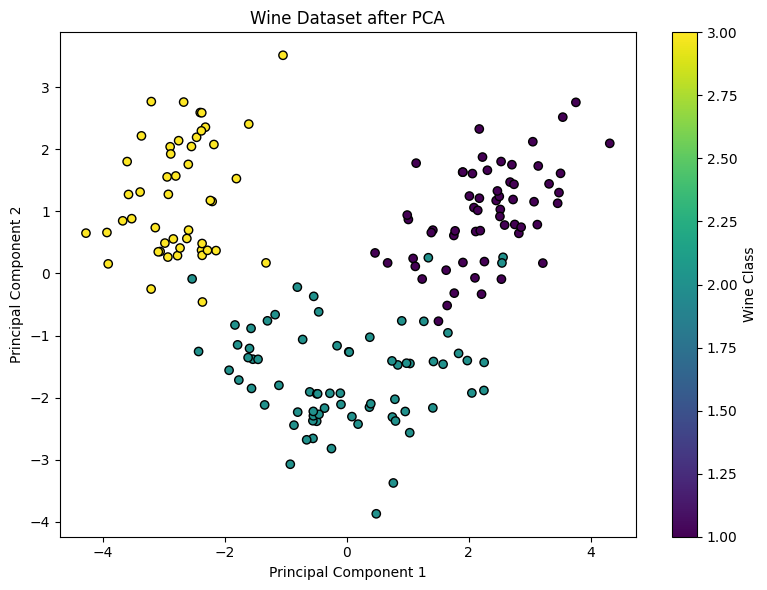

In [11]:
import matplotlib.pyplot as plt

# Visualize the transformed dataset using a two-dimensional scatter plot

plt.figure(figsize=(8, 6))

plt.scatter(
    X_wine_pca[:, 0],
    X_wine_pca[:, 1],
    c=y_wine,
    cmap="viridis",
    edgecolor="black"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset after PCA")
plt.colorbar(label="Wine Class")

plt.tight_layout()
plt.show()

TASK 6. Compare the original and transformed datasets in terms of:

○ Number of features

○ Information retained

○ Computational efficiency


In [12]:
# Compare the original and transformed datasets

original_features = X_wine_scaled.shape[1]
transformed_features = X_wine_pca.shape[1]

variance_retained = pca.explained_variance_ratio_.sum()

print("Comparison of Original and Transformed Dataset")
print()

print("Number of Features:")
print("Original Dataset:", original_features)
print("Transformed Dataset:", transformed_features)

print("\nInformation Retained:")
print(f"Variance Retained by 2 Principal Components: {variance_retained:.4f}")
print(f"Percentage of Variance Retained: {variance_retained * 100:.2f}%")

print("\nComputational Efficiency:")
print("Original Dataset: Higher computational requirement")
print("Transformed Dataset: Lower computational requirement")

Comparison of Original and Transformed Dataset

Number of Features:
Original Dataset: 13
Transformed Dataset: 2

Information Retained:
Variance Retained by 2 Principal Components: 0.5541
Percentage of Variance Retained: 55.41%

Computational Efficiency:
Original Dataset: Higher computational requirement
Transformed Dataset: Lower computational requirement


TASK 7. Interpret the significance of the first two principal components.

Principal Component 1 (PC1) captures the largest amount of variation in the Wine dataset, so it represents the most important overall pattern in the original 13 features.

Principal Component 2 (PC2) captures the second-largest amount of variation and provides additional information that is not captured by PC1.

Together, PC1 and PC2 provide a reduced two-dimensional representation of the original dataset, which can be used to visualize the distribution and separation of the different wine classes.

**Short Inference:**

PC1 is the most significant component because it explains the highest variance, while PC2 explains the next highest variance. Together, they summarize important patterns in the original 13 features and make the dataset easier to visualize.

TASK 8. Discuss the advantages, limitations, and applications of PCA in machine learning.


**Advantages of PCA**

<>Reduces the number of features in a dataset.

<>Makes high-dimensional data easier to visualize.

<>Can reduce computational time and memory requirements.

<>Removes some redundant information from correlated features.


**Limitations of PCA**

<>Some information may be lost during dimensionality reduction.

<>Principal components are combinations of original features and may be difficult to interpret.

<>PCA is sensitive to feature scaling, so standardization is usually required.

<>PCA does not use class labels because it is an unsupervised technique.


**Applications of PCA**

<>Data visualization

<>Image processing

<>Feature reduction

<>Pattern recognition

<>Data preprocessing before machine learning


**Short Inference**

PCA is useful for reducing the dimensionality of high-dimensional datasets while retaining important information. However, it may cause information loss and make the original features harder to interpret. It is commonly used for visualization, preprocessing, and reducing computational complexity.

Extra credit Task :

Apply Linear Discriminant Analysis (LDA) to the same dataset and reduce it to two linear
discriminants. Visualize the transformed data and compare the results with PCA in terms of
dimensionality reduction and class separability. Summarize your observations.

Original Feature Shape:
(178, 13)

LDA Transformed Feature Shape:
(178, 2)


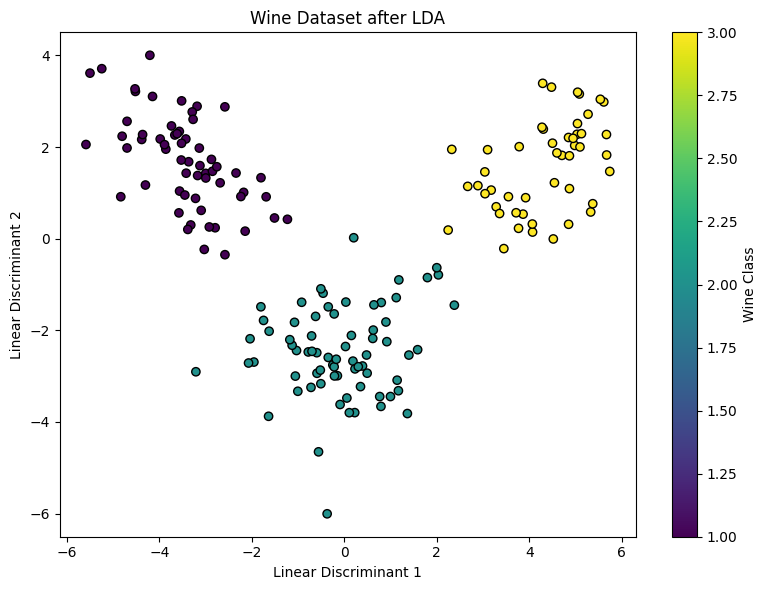

In [13]:
#We will apply LDA to the same standardized Wine dataset, reduce it to 2 linear discriminants, visualize the result, and then compare it with the PCA result.

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

# Apply Linear Discriminant Analysis (LDA)
lda = LinearDiscriminantAnalysis(n_components=2)

X_wine_lda = lda.fit_transform(X_wine_scaled, y_wine)

# Display the transformed shape
print("Original Feature Shape:")
print(X_wine_scaled.shape)

print("\nLDA Transformed Feature Shape:")
print(X_wine_lda.shape)

# Visualize the LDA transformed data
plt.figure(figsize=(8, 6))

plt.scatter(
    X_wine_lda[:, 0],
    X_wine_lda[:, 1],
    c=y_wine,
    cmap="viridis",
    edgecolor="black"
)

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("Wine Dataset after LDA")
plt.colorbar(label="Wine Class")

plt.tight_layout()
plt.show()

OBSERVATION:

Both PCA and LDA reduce the Wine dataset from 13 features to 2 dimensions. PCA focuses on preserving the maximum variance without considering the class labels, whereas LDA uses the class labels to find directions that maximize separation between classes. Therefore, the LDA visualization is generally expected to show clearer separation between the wine classes than PCA, making LDA more suitable when class separability is the main objective.

CONCLUSION

This lab successfully implemented Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction. Different SVM hyperparameter values were explored and the model was evaluated using accuracy, precision, recall, F1-score, and confusion matrix. PCA reduced the Wine dataset from 13 features to 2 principal components, allowing the data to be visualized in a lower-dimensional space while analysing the variance retained. The extra-credit LDA experiment showed how supervised dimensionality reduction can focus on class separability, providing a useful comparison with PCA.